In [61]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv('datasets/All_Diets.csv')

# Sample
df.head()


,Diet_type,Recipe_name,Cuisine_type,Protein(g),Carbs(g),Fat(g),Extraction_day,Extraction_time
0,paleo,Bone Broth From 'Nom Nom Paleo',american,5.22,1.29,3.20,2022-10-16,17:20:09
1,paleo,"Paleo Effect Asian-Glazed Pork Sides, A Sweet ...",south east asian,181.55,28.62,146.14,2022-10-16,17:20:09
2,paleo,Paleo Pumpkin Pie,american,30.91,302.59,96.76,2022-10-16,17:20:09
3,paleo,Strawberry Guacamole recipes,mexican,9.62,75.78,59.89,2022-10-16,17:20:09
4,paleo,"Asian Cauliflower Fried ""Rice"" From 'Nom Nom P...",chinese,39.84,54.08,71.55,2022-10-16,17:20:09


In [62]:
numeric_cols = ['Protein(g)', 'Carbs(g)', 'Fat(g)']

# Z-scores for the numeric columns
z_scores = np.abs(stats.zscore(df[numeric_cols]))

# You can adjust the threshold as needed :D
threshold = 1.75

# Berapa rows yang ada di Z-scores yang melebihi threshold
outliers_z = df[(z_scores > threshold).any(axis=1)]

print(f"Number of outliers detected using Z-Score: {outliers_z.shape[0]}")

# Sample
outliers_z.head()


Number of outliers detected using Z-Score: 988


,Diet_type,Recipe_name,Cuisine_type,Protein(g),Carbs(g),Fat(g),Extraction_day,Extraction_time
8,paleo,Baked Banana Chip Encrusted French Toast,french,152.88,1874.52,385.80,2022-10-16,17:20:09
9,paleo,Vietnamese Pho Pressure Cooker (Noodle Soup),south east asian,602.91,274.87,400.01,2022-10-16,17:20:09
16,paleo,Magic Wings recipes,american,320.76,28.36,252.82,2022-10-16,17:20:16
20,paleo,Chocolate Pecan Pie recipes,american,59.86,567.39,320.76,2022-10-16,17:20:16
22,paleo,Chocolate Pecan Pie,american,54.70,503.39,320.12,2022-10-16,17:20:16


In [63]:
# Inisialisasi DataFrame kosong untuk menyimpan outliers
outliers_iqr = pd.DataFrame()

# Iterasikan setiap kolom numerik untuk menemukan outlier
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identifikasi outliers dalam kolom saat ini
    outlier_col = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    # Add ke DataFrame outliers
    outliers_iqr = pd.concat([outliers_iqr, outlier_col])

# Remove duplicate rows maybe
outliers_iqr = outliers_iqr.drop_duplicates()

print(f"Number of outliers detected using IQR: {outliers_iqr.shape[0]}")

# Sample
outliers_iqr.head()


Number of outliers detected using IQR: 992


,Diet_type,Recipe_name,Cuisine_type,Protein(g),Carbs(g),Fat(g),Extraction_day,Extraction_time
9,paleo,Vietnamese Pho Pressure Cooker (Noodle Soup),south east asian,602.91,274.87,400.01,2022-10-16,17:20:09
16,paleo,Magic Wings recipes,american,320.76,28.36,252.82,2022-10-16,17:20:16
75,paleo,Paleo Party Pork Carnitas,mexican,268.92,128.88,334.28,2022-10-16,17:20:50
84,paleo,Instant Pot Paleo Pork Tenderloin,french,362.76,16.83,64.04,2022-10-16,17:20:56
85,paleo,Paleo Pecan-Crusted Chicken | everydaypaleo.com,american,258.66,55.59,103.91,2022-10-16,17:20:56


In [64]:
print("=== Outlier Detection Summary ===")
print(f"Total rows in dataset: {df.shape[0]}")
print(f"Outliers detected using Z-Score: {outliers_z.shape[0]}")
print(f"Outliers detected using IQR: {outliers_iqr.shape[0]}")

# Common outliers dari kedua methods
common_outliers = pd.merge(outliers_z, outliers_iqr, how='inner')

print(f"Number of common outliers detected by both methods: {common_outliers.shape[0]}")

# Outliers hanya Z-Score
only_z = outliers_z[~outliers_z.index.isin(outliers_iqr.index)]
print(f"Outliers detected only by Z-Score: {only_z.shape[0]}")

# Outliers hanya IQR
only_iqr = outliers_iqr[~outliers_iqr.index.isin(outliers_z.index)]
print(f"Outliers detected only by IQR: {only_iqr.shape[0]}")


=== Outlier Detection Summary ===
Total rows in dataset: 7806
Outliers detected using Z-Score: 988
Outliers detected using IQR: 992
Number of common outliers detected by both methods: 966
Outliers detected only by Z-Score: 22
Outliers detected only by IQR: 26


Visualizing Z-Score Outliers


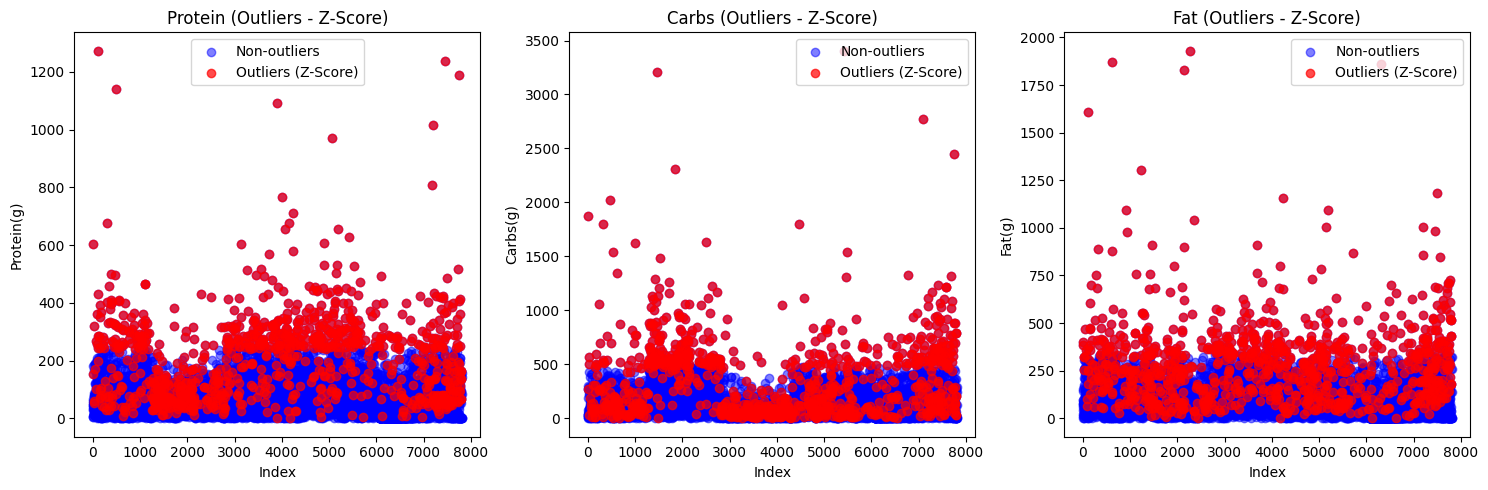

Visualizing IQR Outliers


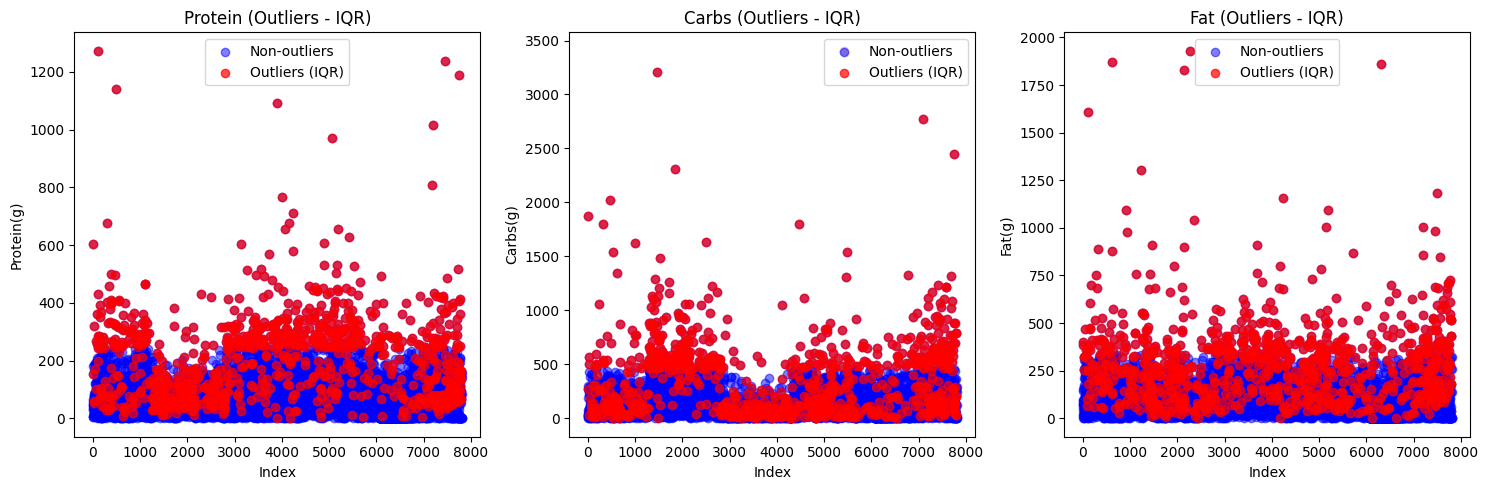

In [66]:
import matplotlib.pyplot as plt

# Scatter plot for Protein, Carbs, and Fat showing Z-Score outliers
def plot_outliers(df, outliers, method_name):
    plt.figure(figsize=(15, 5))

    # Plot Protein
    plt.subplot(1, 3, 1)
    plt.scatter(df.index, df['Protein(g)'], label='Non-outliers', color='blue', alpha=0.5)
    plt.scatter(outliers.index, outliers['Protein(g)'], label=f'Outliers ({method_name})', color='red', alpha=0.7)
    plt.title(f'Protein (Outliers - {method_name})')
    plt.xlabel('Index')
    plt.ylabel('Protein(g)')
    plt.legend()

    # Plot Carbs
    plt.subplot(1, 3, 2)
    plt.scatter(df.index, df['Carbs(g)'], label='Non-outliers', color='blue', alpha=0.5)
    plt.scatter(outliers.index, outliers['Carbs(g)'], label=f'Outliers ({method_name})', color='red', alpha=0.7)
    plt.title(f'Carbs (Outliers - {method_name})')
    plt.xlabel('Index')
    plt.ylabel('Carbs(g)')
    plt.legend()

    # Plot Fat
    plt.subplot(1, 3, 3)
    plt.scatter(df.index, df['Fat(g)'], label='Non-outliers', color='blue', alpha=0.5)
    plt.scatter(outliers.index, outliers['Fat(g)'], label=f'Outliers ({method_name})', color='red', alpha=0.7)
    plt.title(f'Fat (Outliers - {method_name})')
    plt.xlabel('Index')
    plt.ylabel('Fat(g)')
    plt.legend()

    plt.tight_layout()
    plt.show()

print("Visualizing Z-Score Outliers")
plot_outliers(df, outliers_z, "Z-Score")

print("Visualizing IQR Outliers")
plot_outliers(df, outliers_iqr, "IQR")